## 🧠 Why Traversal Matters

Traversal helps answer:

* Can node A reach node B?
* What is the shortest path?
* How does money flow in fraud?


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

import pandas as pd


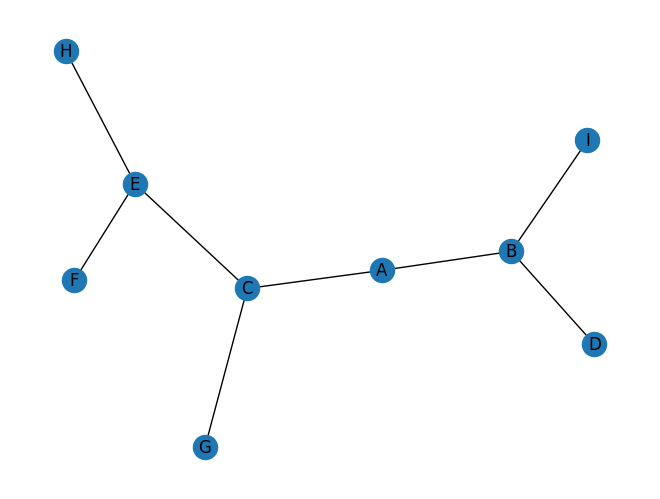

In [6]:
## 🔹 Create Sample Graph

G = nx.Graph()
edges = [("A","B"), ("A","C"), ("B","D"), ("C","E"), ("E","F"), ("C","G"), ("E","H"), ("B", "I")]
G.add_edges_from(edges)

nx.draw(G, with_labels=True)
plt.show()


In [7]:
## 🔹 Breadth-First Search (BFS)

bfs_nodes = list(nx.bfs_tree(G, source="A"))
print("BFS Traversal:", bfs_nodes)

BFS Traversal: ['A', 'B', 'C', 'D', 'I', 'E', 'G', 'F', 'H']


In [8]:
## 🔹 Depth-First Search (DFS)

dfs_nodes = list(nx.dfs_tree(G, source="A"))
print("DFS Traversal:", dfs_nodes)

DFS Traversal: ['A', 'B', 'D', 'I', 'C', 'E', 'F', 'H', 'G']


## 🌳 Tree View from A

Draw the graph as a tree rooted at `A`, with each BFS layer on its own level. This makes the traversal order easier to see.

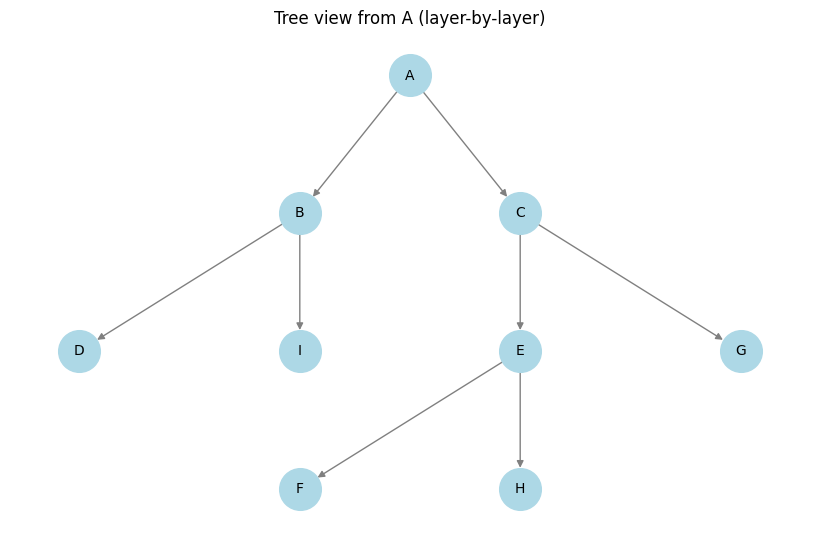

In [9]:
# Build a layered position map for the BFS tree

def layered_tree_pos(G, root):
    depths = nx.single_source_shortest_path_length(G, root)
    layers = {}
    for node, depth in depths.items():
        layers.setdefault(depth, []).append(node)

    pos = {}
    for depth in sorted(layers):
        layer = layers[depth]
        width = len(layer)
        for i, node in enumerate(layer):
            pos[node] = (i - (width - 1) / 2, -depth)
    return pos

# Use the BFS tree so each node appears in the order it is first discovered
bfs_tree = nx.bfs_tree(G, source="A")
pos = layered_tree_pos(bfs_tree, "A")

plt.figure(figsize=(8, 5))
nx.draw(bfs_tree, pos, with_labels=True, node_color='lightblue', node_size=900, font_size=10, edge_color='gray')
plt.title("Tree view from A (layer-by-layer)")
plt.axis('off')
plt.show()

In [10]:
## 🔹 Shortest Path

path = nx.shortest_path(G, source="A", target="F")
print("Shortest path from A to F:", path)

Shortest path from A to F: ['A', 'C', 'E', 'F']


In [13]:
## 🔹 Fraud Use Case

# Example: Detect money flow from fraud account

fraud_path = nx.shortest_path(G, source="A", target="F")
print("Suspicious path:", fraud_path)

Suspicious path: ['A', 'C', 'E', 'F']


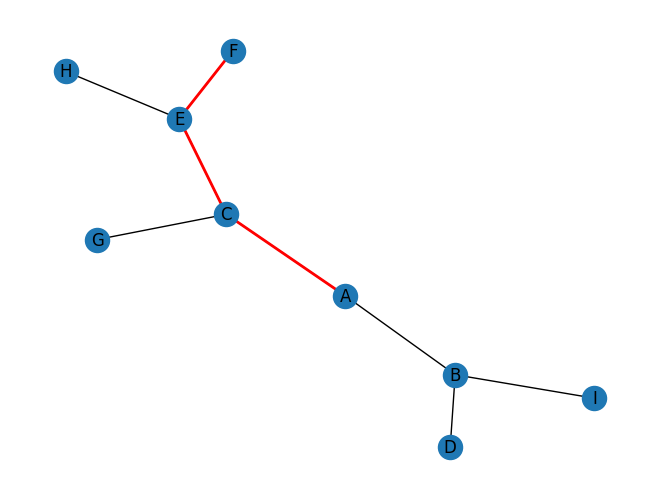

In [14]:
## 🔹 Visualize Path

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)

# Highlight path
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='r', width=2)

plt.show()

## ✅ Summary

* BFS → level-wise traversal
* DFS → depth-wise traversal
* Shortest path → key for fraud detection
